# 1) Analyse descriptive des données

Descritption générale : Dans ce projet on va entrainer notre modèle sur le jeu de données ASVspoof 2019.
Ce data set contient deux types de fichiers audio, les PA (Adresses Physiques) et les LA (Adresses Logiques). Nous utiliserons les LA pour notre projet car ce sont des audios générés par IA. Les PA sont des relectures d'enregistrements déjà existant, donc pas utiles pour notre projet.
On va utiliser deux sous-ensembles fournies avec le data set, train pour l'entrainement du modèle et dev pour la validation et l'évaluation.

Description des données : les audios présents dans le jeu de données LA sont de deux types,
spoof (audios synthétiques) et bonafide (audios réel). 
Les données d'entrainement sont labéllées dans le fichier ASVspoof2019.LA.cm.train.trn.txt et celles d'évaluation dans le fichier ASVspoof2019.LA.cm.dev.trl.txt. Ils indiquent pour chaque audio si c'est un enregistrement réél ou synthétique.

Organisation du projet : on a décidé de séparer nos fonctions de notre notebook pour le garder propre, elles sont donc ranger dans un dossier src.  

In [2]:
import sys
from pathlib import Path

SRC_DIR = Path(r"C:\Users\norab\Documents\Cours_ESILV_A4\Machine Learning\deepfake-audio-project\src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from data_utils import load_asvspoof_protocol, attach_paths_by_utt
import pandas as pd
import matplotlib.pyplot as plt
DATA_ROOT = Path(r"C:\Users\norab\Documents\Cours_ESILV_A4\Machine Learning\deepfake-audio-project\archive\LA")
PROTO_TRAIN = DATA_ROOT / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.train.trn.txt"
PROTO_DEV   = DATA_ROOT / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.dev.trl.txt"
AUDIO_ROOT_TRAIN  = DATA_ROOT / "ASVspoof2019_LA_train" / "flac"
AUDIO_ROOT_DEV   = DATA_ROOT / "ASVspoof2019_LA_dev" / "flac"

train_df = attach_paths_by_utt(load_asvspoof_protocol(PROTO_TRAIN), AUDIO_ROOT_TRAIN)
dev_df   = attach_paths_by_utt(load_asvspoof_protocol(PROTO_DEV), AUDIO_ROOT_DEV)
print(train_df.head())

            utt  is_spoof                                               path
0  LA_T_1138215         0  C:\Users\norab\Documents\Cours_ESILV_A4\Machin...
1  LA_T_1271820         0  C:\Users\norab\Documents\Cours_ESILV_A4\Machin...
2  LA_T_1272637         0  C:\Users\norab\Documents\Cours_ESILV_A4\Machin...
3  LA_T_1276960         0  C:\Users\norab\Documents\Cours_ESILV_A4\Machin...
4  LA_T_1341447         0  C:\Users\norab\Documents\Cours_ESILV_A4\Machin...


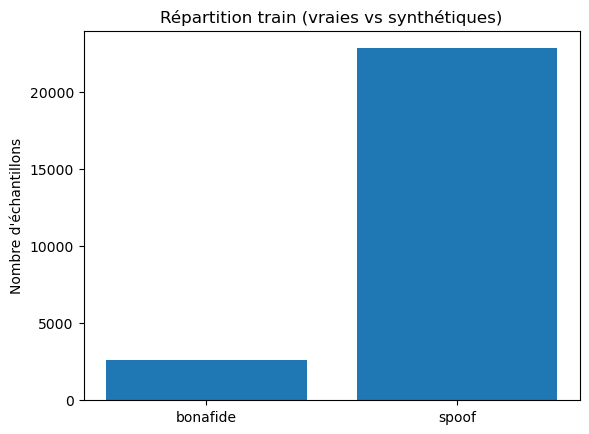

is_spoof
0     2580
1    22800
Name: count, dtype: int64
Nombre total d'échantillons : 25380
Fichiers manquants : 0


In [3]:
counts = train_df["is_spoof"].value_counts().sort_index()

plt.bar(["bonafide", "spoof"], counts.values)
plt.title("Répartition train (vraies vs synthétiques)")
plt.ylabel("Nombre d'échantillons")
plt.show()

print(counts)
print("Nombre total d'échantillons :", len(train_df))
print("Fichiers manquants :", train_df['path'].isna().sum())

On observe que notre dataset est fortement déséquilibré, 
on pourrait le ré-équilibrer mais dans le jeu de données qu'on a choisi, ce déséquilibre est intentionel pour pouvoir entrainer notre model correctement. 

# 2) Pré-Traitement

Pour le pré-traitement on n'extrait pas tous les fichiers audio car ça nous prendrait trop de temps, on va seulement en extraire 500 pour l'entrainement et 200 pour l'évaluation.

In [7]:
import numpy as np
import librosa #bibliothèque utiliser pour le traitement de fichiers audio 
#(nous permet de charger les fichiers .flac et d'extraire les coefficient MFCC)

def extract_features(path, sr=16000, n_mfcc=13):
    y, _ = librosa.load(path, sr=sr) #chargement des fichiers .flac
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc) # calcul des coefs MFCC 
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)]) #concatenation des coeficients MFCC moyennes et écart-types

# recuperation de l'echantillon
sample_train = train_df.sample(500, random_state=42)
sample_dev   = dev_df.sample(200, random_state=42)

#extraction des vecteurs MFCC pour le train et le dev
X_train = np.vstack([extract_features(p) for p in sample_train["path"]])
y_train = sample_train["is_spoof"].to_numpy()

X_dev = np.vstack([extract_features(p) for p in sample_dev["path"]])
y_dev = sample_dev["is_spoof"].to_numpy()

print(X_train.shape, X_dev.shape)

#sauvegarde des MFCC
save_dir = Path(r"C:\Users\norab\Documents\Cours_ESILV_A4\Machine Learning\deepfake-audio-project\data")
save_dir.mkdir(exist_ok=True)

np.save(save_dir / "X_train_mfcc.npy", X_train)
np.save(save_dir / "y_train.npy", y_train)
np.save(save_dir / "X_dev_mfcc.npy", X_dev)
np.save(save_dir / "y_dev.npy", y_dev)


(500, 26) (200, 26)


# 3) Formalisation du problème
Notre problème est un problème de classification binaire supervisée.
En entrée on a l'extrait d'un audio qu'on converti en un vecteur de caractéristiques MFCC.
Et en sortie un label binaire 1 si spoof 0 si non.
On veut un modèle capable de distinguer les spoof des vrais audios.
On évalue notre modèles grâce aux métriques suivantes : 
Accuracy : proportion de bonnes prédictions.
AUC : qualité de la séparation entre vraies et fausses voix.
EER (Equal Error Rate) : point où le taux de fausses alertes est égal au taux d’erreurs de rejet.

# 4) Modèle de base
On a décidé de commencer par une approche classique utilisant un SVM (Support Vector Machine) qui sera entraîné sur les coefficients MFCC moyens et écart-types de chaque échantillon.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

clf = make_pipeline(StandardScaler(), SVC(probability=True, kernel='rbf', C=2.0, gamma='scale'))
clf.fit(X_train, y_train)

y_pred = clf.predict(X_dev)
y_prob = clf.predict_proba(X_dev)[:, 1]

print("Accuracy :", accuracy_score(y_dev, y_pred))
print("AUC :", roc_auc_score(y_dev, y_prob))
print("Confusion matrix :\n", confusion_matrix(y_dev, y_pred))


Accuracy : 0.93
AUC : 0.9256114130434783
Confusion matrix :
 [[  4  12]
 [  2 182]]


Conclusion : on remarque que notre modèle a un biais pro-spoof dû au déséquilibre important de notre dataset.